# Day 6: validation-only selection, thresholding and explainability

This notebook reads saved Day 6 artefacts. It does not refit a model, rerun SHAP, select a new threshold, or load final-test outcomes.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
metrics = json.loads((REPORTS / 'day6_validation_analysis_metrics.json').read_text())
threshold = json.loads((REPORTS / 'day6_selected_threshold.json').read_text())
uncertainty = json.loads((REPORTS / 'day6_paired_ap_uncertainty.json').read_text())
comparison = pd.read_csv(REPORTS / 'day6_validation_model_comparison.csv')
assert not metrics['final_test_outcomes_materialised']
assert not metrics['final_test_evaluated']
comparison

,model,roc_auc,average_precision,selection_status
0,Random Forest,0.771917,0.539980,provisional primary candidate
1,XGBoost,0.771792,0.536643,comparison model
2,Logistic Regression,0.754405,0.519471,comparison model


## Paired uncertainty and frozen threshold

In [2]:
pd.Series({
    'RF minus XGBoost AP': uncertainty['ap_difference_random_forest_minus_xgboost'],
    '95% CI lower': uncertainty['confidence_interval_lower'],
    '95% CI upper': uncertainty['confidence_interval_upper'],
    'Interval includes zero': uncertainty['interval_includes_zero'],
    'Superiority claimed': metrics['superiority_claimed'],
    'Selected threshold': threshold['threshold'],
    'Precision': threshold['precision'],
    'Recall': threshold['recall'],
    'False-positive rate': threshold['false_positive_rate'],
    'Proportion flagged': threshold['proportion_flagged'],
})

RF minus XGBoost AP       0.003336
95% CI lower             -0.007522
95% CI upper              0.013794
Interval includes zero        True
Superiority claimed          False
Selected threshold        0.191264
Precision                  0.41088
Recall                    0.700075
False-positive rate       0.285042
Proportion flagged        0.376833
dtype: object

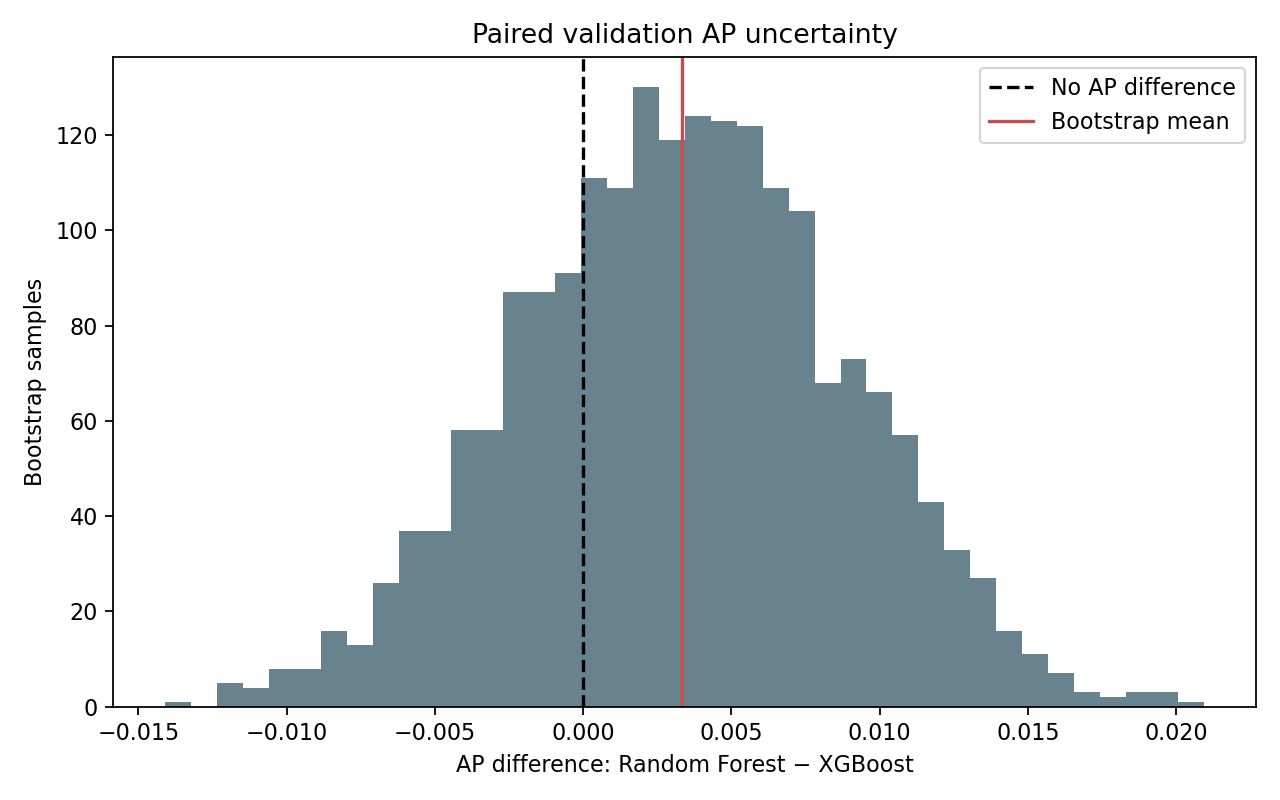

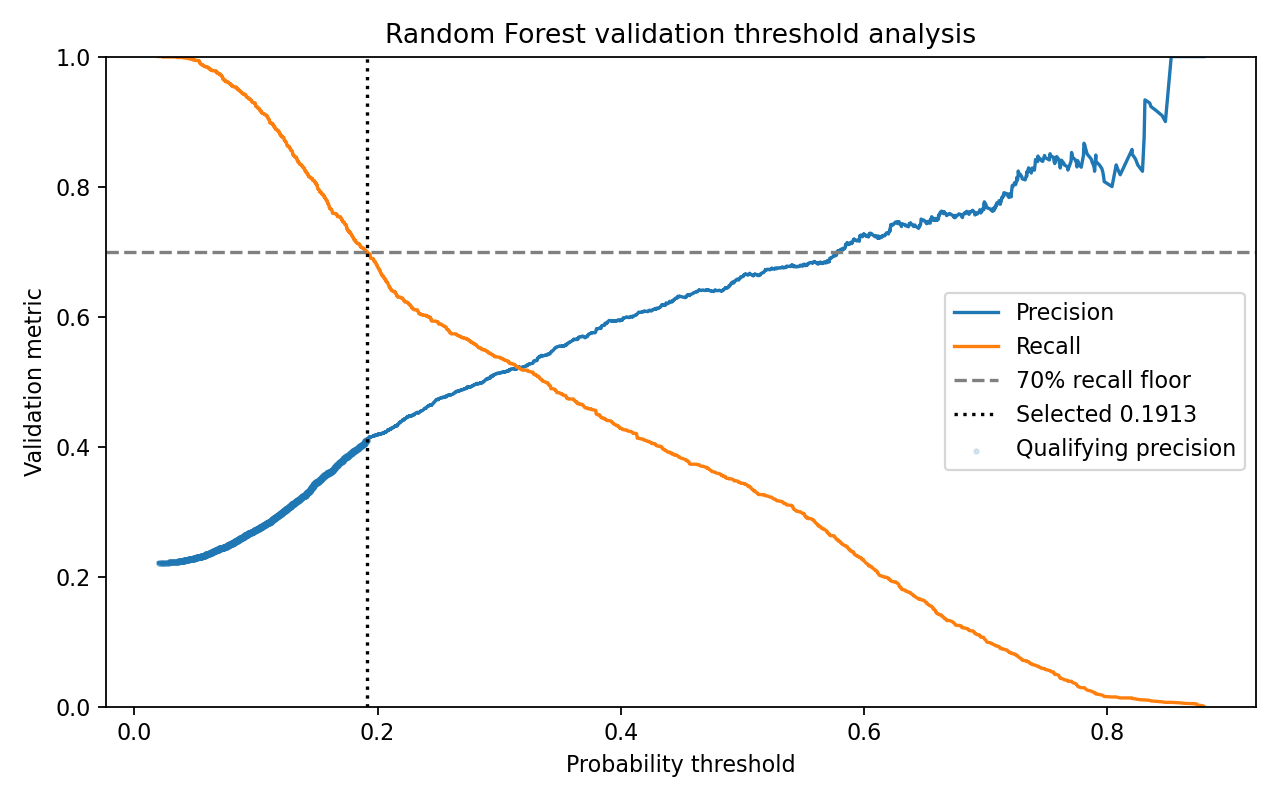

In [3]:
display(Image(filename=str(FIGURES / 'day6_paired_ap_bootstrap.png')))
display(Image(filename=str(FIGURES / 'day6_threshold_tradeoff.png')))

## Global Tree SHAP

Global SHAP uses the documented deterministic 1,000-row class-stratified validation sample. Values describe model associations, not causal effects; correlated predictors can divide or mask contributions.

,source_feature,mean_absolute_shap,mean_signed_shap
0,PAY_0,0.053069,0.001350
1,PAY_2,0.028073,-0.001555
2,LIMIT_BAL,0.018341,-0.000576
3,PAY_3,0.017764,0.000916
4,PAY_4,0.015479,0.000365
5,PAY_AMT1,0.013475,-0.001790
6,PAY_5,0.011427,-0.001199
7,PAY_6,0.010664,-0.000279
8,PAY_AMT2,0.009024,-0.000395
9,PAY_AMT3,0.009000,0.000134


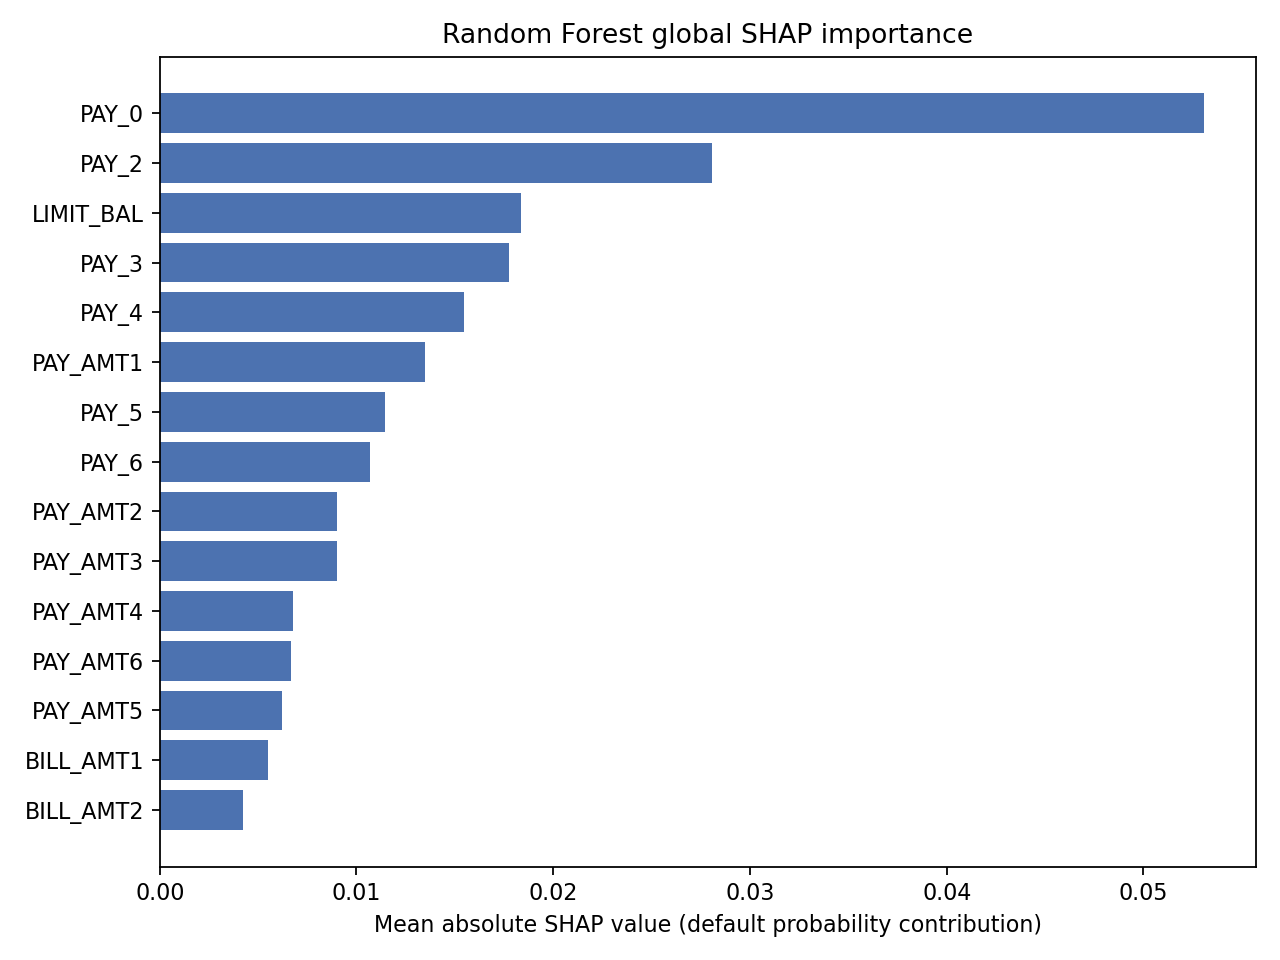

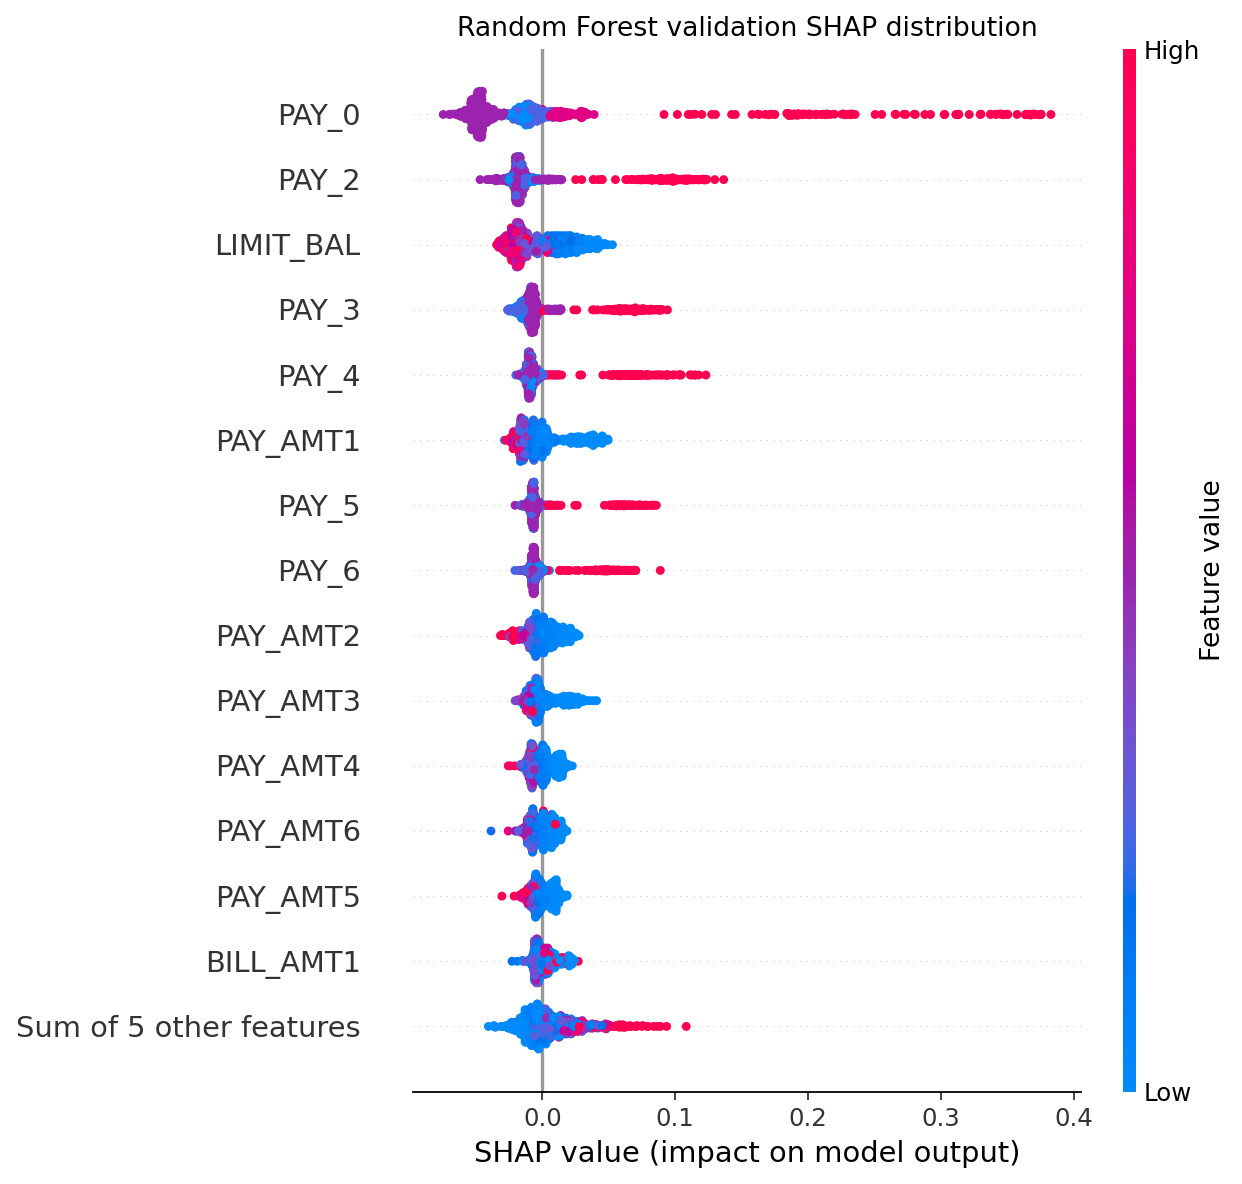

In [4]:
global_shap = pd.read_csv(REPORTS / 'day6_random_forest_global_shap_source.csv')
display(global_shap.head(10))
display(Image(filename=str(FIGURES / 'day6_random_forest_global_shap_bar.png')))
display(Image(filename=str(FIGURES / 'day6_random_forest_global_shap_beeswarm.png')))

## Three clearly labelled validation cases

,actual_class,case_label,predicted_class,predicted_probability,selection_method,threshold
0,1,true_positive,1,0.879238,highest score in category,0.191264
1,0,false_positive,1,0.847720,highest score in category,0.191264
2,1,false_negative,0,0.022591,lowest score in category,0.191264


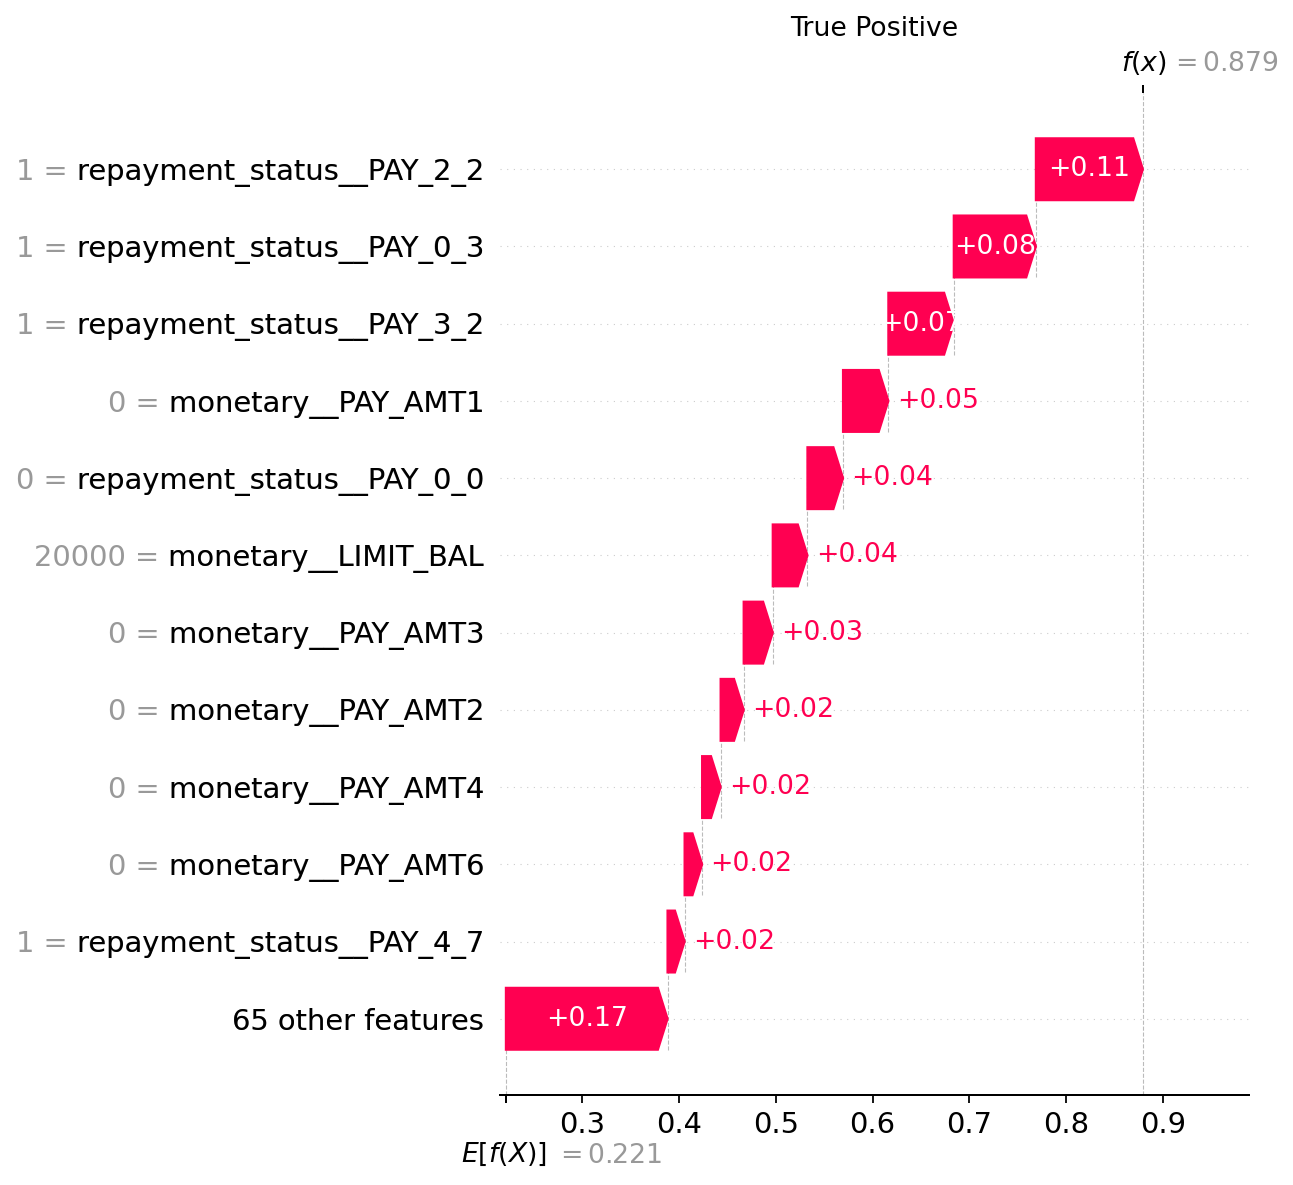

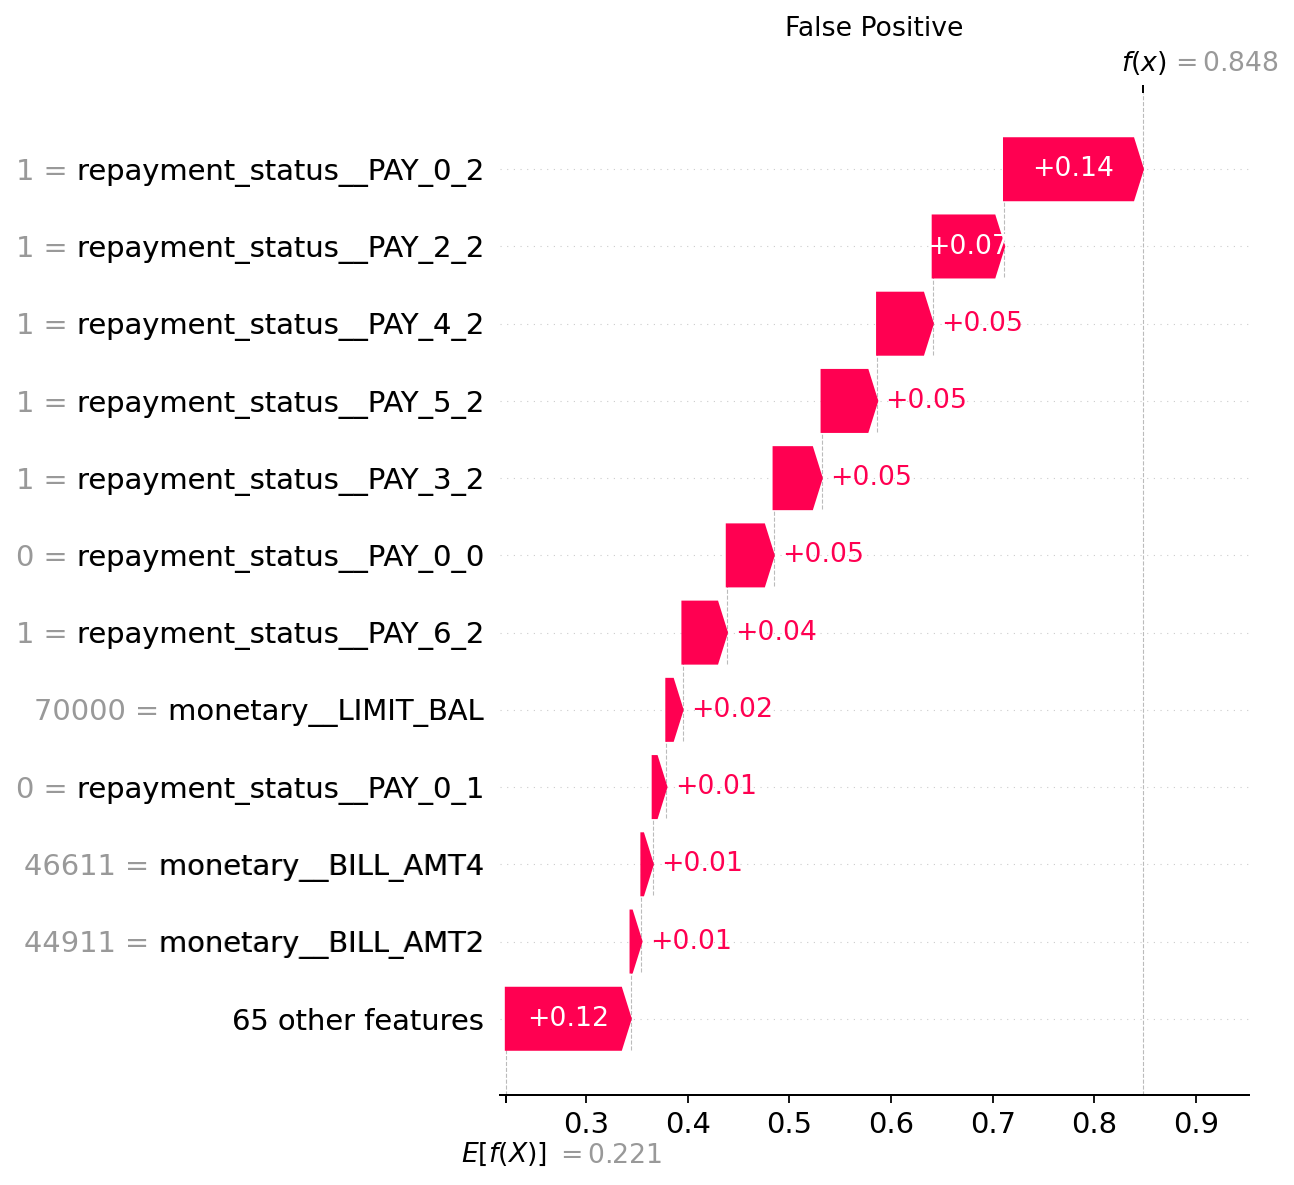

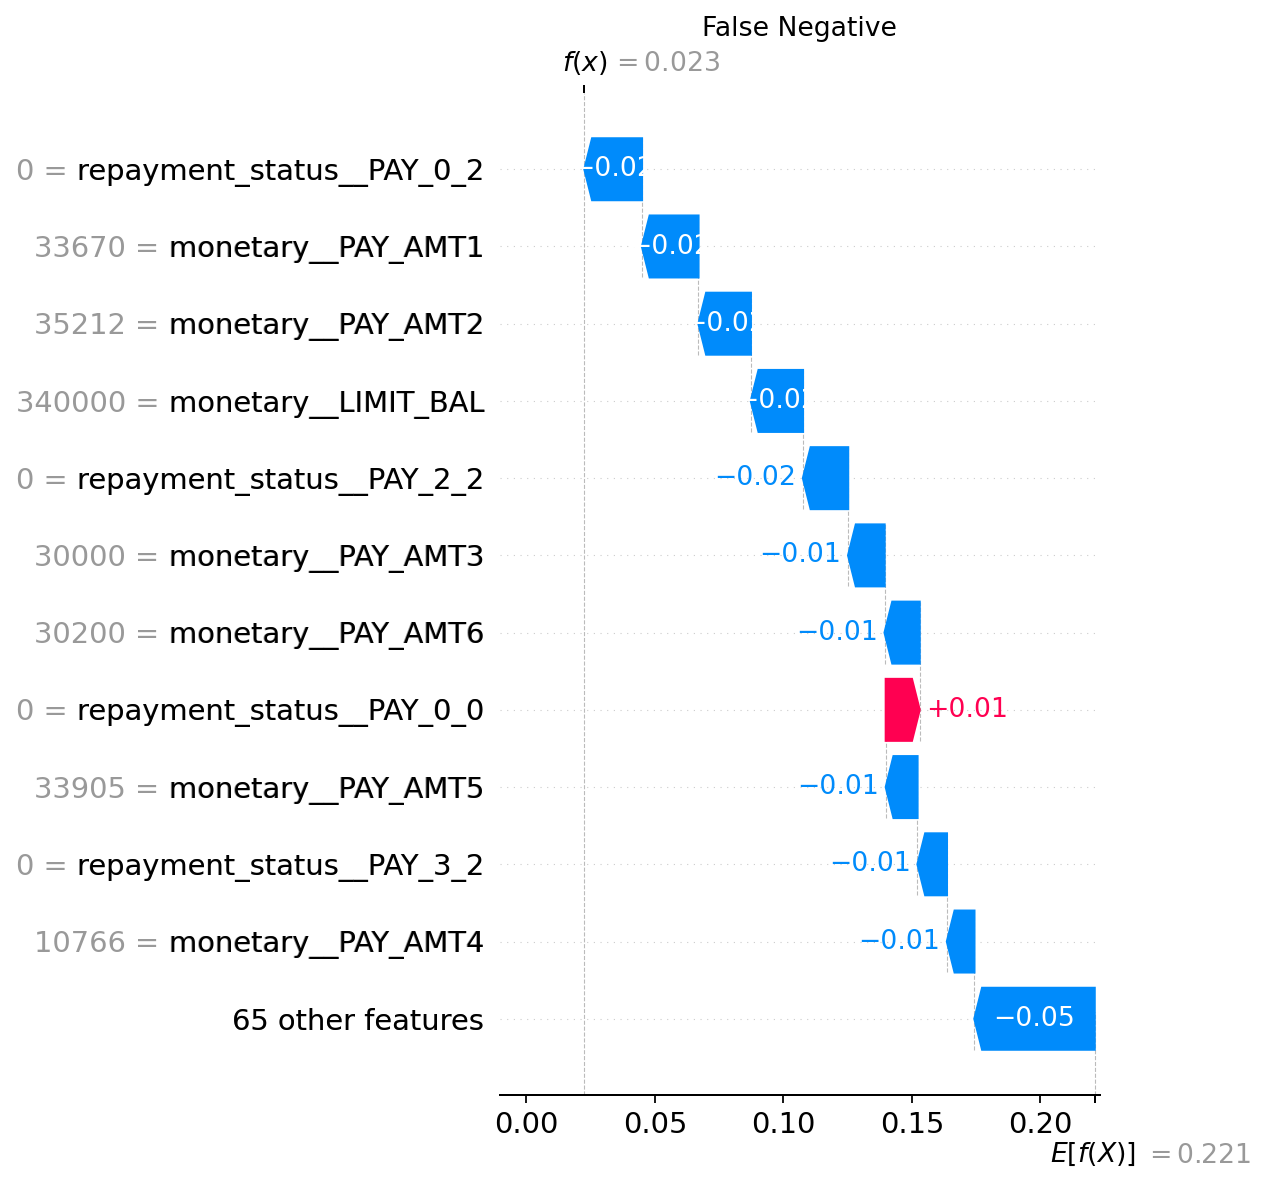

In [5]:
case_metadata = pd.DataFrame(json.loads((REPORTS / 'day6_case_level_metadata.json').read_text()))
display(case_metadata)
for label in ('true_positive', 'false_positive', 'false_negative'):
    display(Image(filename=str(FIGURES / f'day6_case_{label}_shap_waterfall.png')))

## Aggregate false-positive and false-negative analysis

,outcome_group,rows,proportion_of_validation,mean_probability,median_probability
0,true_positive,929,0.154833,0.481830,0.491147
1,false_positive,1332,0.222000,0.350448,0.304759
2,false_negative,398,0.066333,0.127556,0.130363
3,true_negative,3341,0.556833,0.111203,0.111697


,error_group,source_feature,rows,mean,median,most_frequent_value,validation_mean,validation_median
0,false_positive,LIMIT_BAL,1332,129774.774775,90000.0,50000.0,167411.666667,140000.0
1,false_positive,PAY_0,1332,0.271772,0.0,1.0,-0.013667,0.0
2,false_positive,PAY_2,1332,0.055556,0.0,0.0,-0.143000,0.0
3,false_positive,PAY_3,1332,0.023273,0.0,0.0,-0.163167,0.0
4,false_positive,PAY_4,1332,-0.044294,0.0,0.0,-0.207500,0.0
5,false_positive,PAY_5,1332,-0.196697,0.0,0.0,-0.254667,0.0
6,false_positive,PAY_6,1332,-0.259009,0.0,0.0,-0.277000,0.0
7,false_positive,BILL_AMT1,1332,32503.855105,9159.0,0.0,52274.112833,23625.5
8,false_positive,BILL_AMT2,1332,32316.114865,8305.0,0.0,50735.480000,22636.0
9,false_positive,BILL_AMT3,1332,31866.906156,8524.0,0.0,48627.940667,21118.0


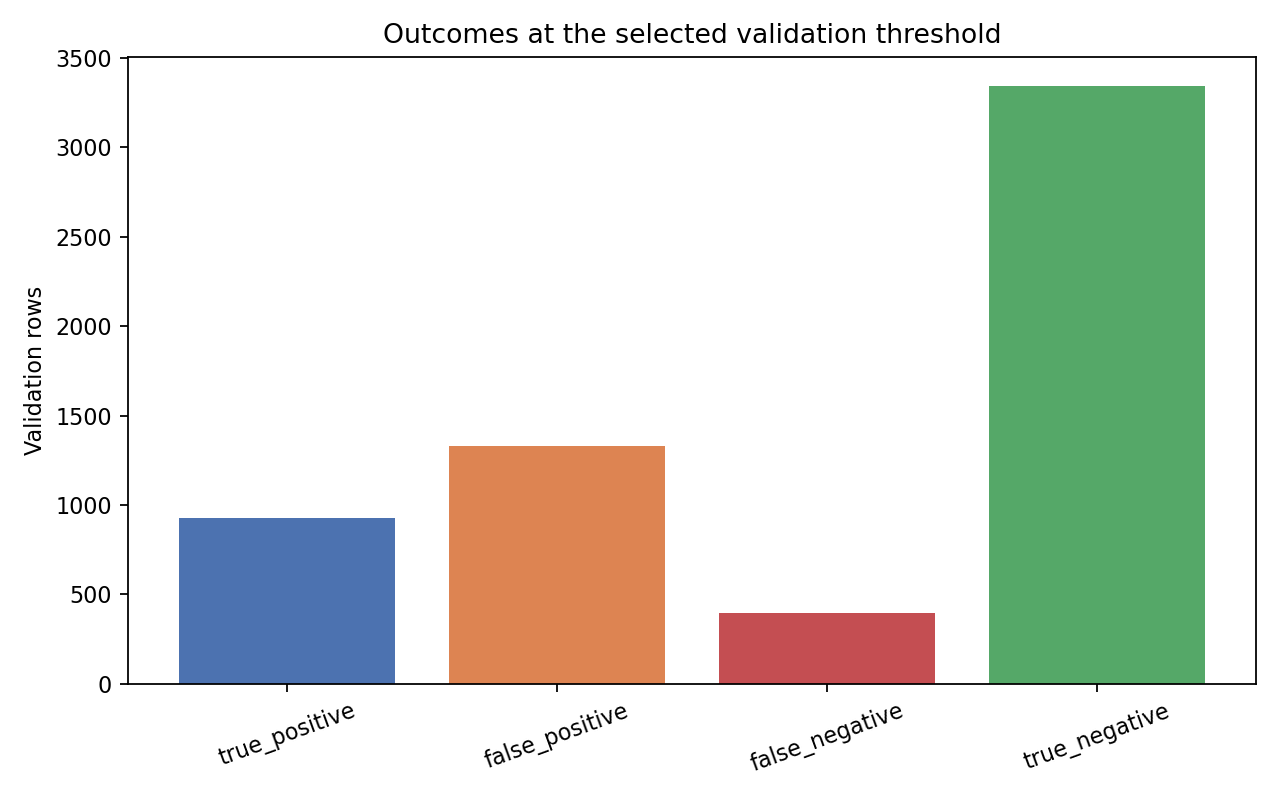

In [6]:
error_groups = pd.read_csv(REPORTS / 'day6_error_group_summary.csv')
error_features = pd.read_csv(REPORTS / 'day6_error_feature_summary.csv')
display(error_groups)
display(error_features.head(12))
display(Image(filename=str(FIGURES / 'day6_validation_error_counts.png')))

The 70% recall floor is an illustrative portfolio assumption, not a regulatory or real lending standard. The validation-selected threshold must not be revised using the final test set. No final generalisation claim is made.